In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Task1 7x7 Box Filter

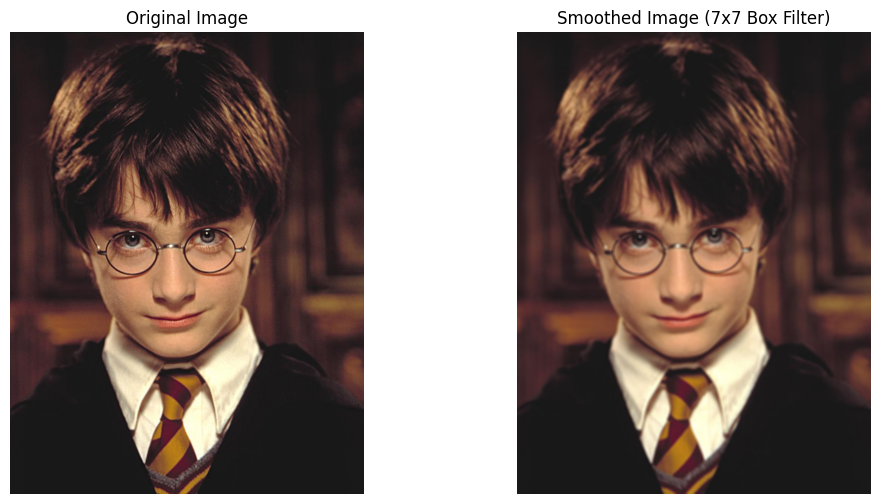

In [2]:
# Read the image
image = cv2.imread('HP1.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convolve with a 7x7 box filter
# cv2.blur is the standard function for a normalized box filter
smoothed_image = cv2.blur(image_rgb, (7, 7))

# Output original and smoothed image side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(image_rgb)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(smoothed_image)
ax[1].set_title("Smoothed Image (7x7 Box Filter)")
ax[1].axis("off")

plt.show()

### Task 2 Gaussian Filtering (5x5 and 21x21)

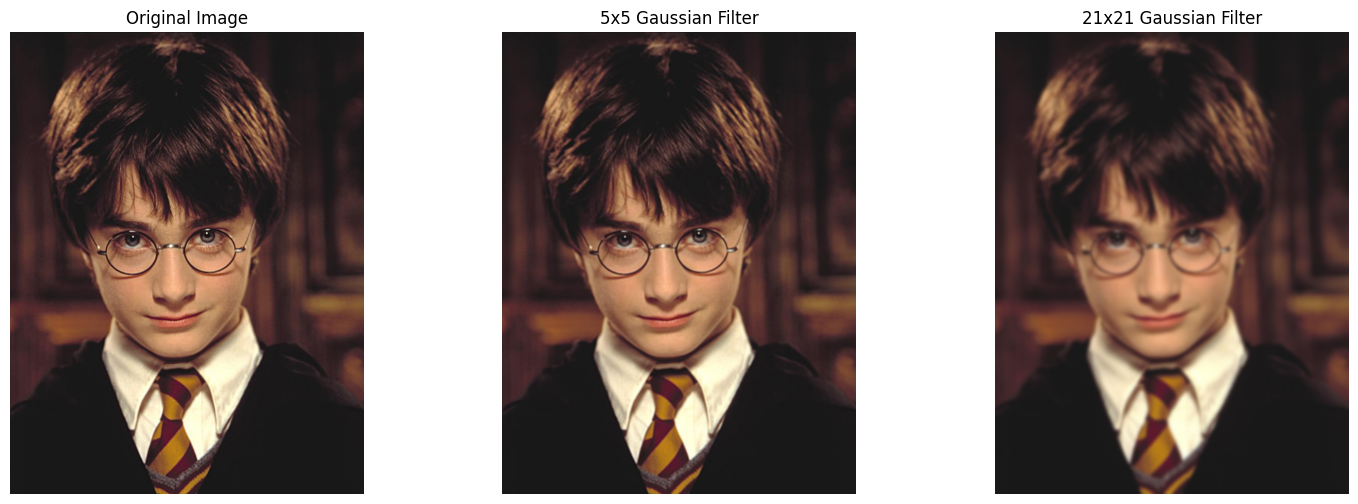

In [3]:
# Apply a 5x5 Gaussian filter
gaussian_5 = cv2.GaussianBlur(image_rgb, (5, 5), 0)

# Apply a 21x21 Gaussian filter
gaussian_21 = cv2.GaussianBlur(image_rgb, (21, 21), 0)

# Show the three images side by side
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(image_rgb)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(gaussian_5)
ax[1].set_title("5x5 Gaussian Filter")
ax[1].axis("off")

ax[2].imshow(gaussian_21)
ax[2].set_title("21x21 Gaussian Filter")
ax[2].axis("off")

plt.show()

### Task 3 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.8470585].


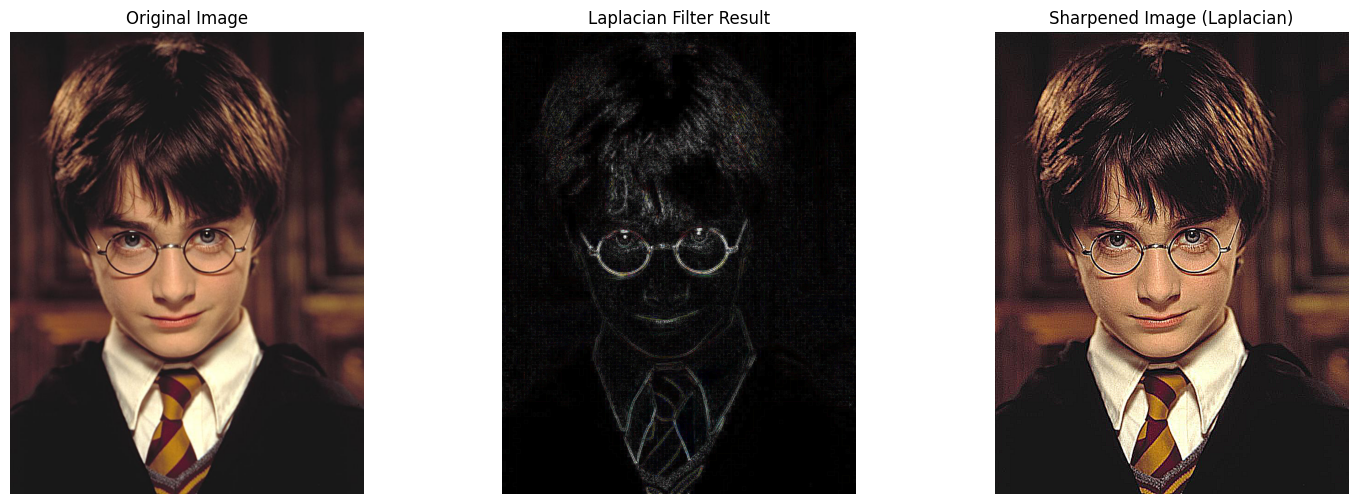

In [4]:
# 1. Read and convert the image to float32
image_float = image_rgb.astype(np.float32) / 255.0

# 2. Use the cv2.Laplacian() function [cite: 52]
# ksize=3 indicates a 3x3 filter
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=3)

# 3. Sharpen the image using the provided formula 
sharpened = np.clip(image_float - laplacian, 0, 1)

# 4. Plot original, Laplacian, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(image_float)
ax[0].set_title("Original Image")
ax[0].axis("off")

# We visualize the absolute value of the Laplacian to see the edges clearly
ax[1].imshow(np.absolute(laplacian), cmap='gray')
ax[1].set_title("Laplacian Filter Result")
ax[1].axis("off")

ax[2].imshow(sharpened)
ax[2].set_title("Sharpened Image (Laplacian)")
ax[2].axis("off")

plt.show()